# Neural Network for MNIST classification

In this hometask you'll implement and train neural network for classification of images of MNIST dataset.

MNIST is a dataset of grayscale images of handwritten digits. Each image has a size of 28*28. The images are divided into 10 classes depending on which of the ten digits is depicted in the image. The images look like this:

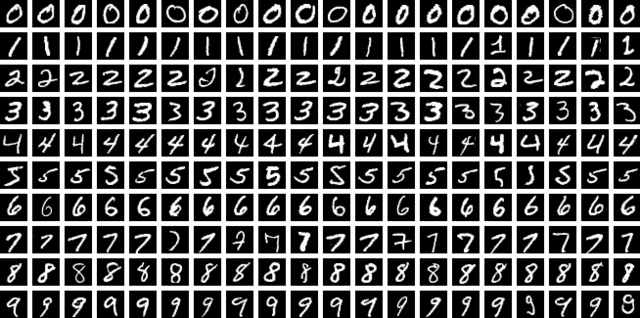

## Loading data

The cell below downloads MNIST dataset in a form of csv file

In [ ]:
! pip install wldhx.yadisk-direct
! curl -L $(yadisk-direct https://disk.yandex.com/d/rWEouTV8E1F-CA) -o MNIST_csv.zip
! unzip -qq MNIST_csv.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100 14.7M  100 14.7M    0     0  2485k      0  0:00:06  0:00:06 --:--:-- 3667k


After this, you'll have a directory named `MNIST_csv` with two files, representing training and testing splits of MNIST data.

Let's import Numpy, Pandas and look at our data:

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
train_data = pd.read_csv('./MNIST_csv/mnist_train.csv')
train_data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In this file, each image is represented as vector of size 28*28=784, with each feature representing one pixel of the image. Values of pixels are in the range [0, 255], where 0 is black pixel and 255 is white.

Column `label` is a target variable, representing a digit that is depicted on the image.

Let's visualize the first image:

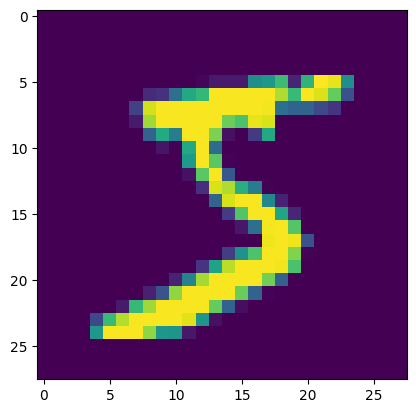

In [ ]:
import matplotlib.pyplot as plt

img = np.array(train_data.iloc[0][1:])
plt.imshow(img.reshape(28, 28));

Let's also load test data:

In [ ]:
# loading the test data
test_data = pd.read_csv('./MNIST_csv/mnist_test.csv')

## Task 1. Binary classification with NNs


In this first task you'll define and train neural network for binary classification of MNIST images.

As we have 10 classes in the full dataset, we'll need to extract subpart of the data that contains only two digits.

We will try to solve two tasks: classification of digits that look different (e.g. 0 and 1) and classification of digits that look similar (e.g. 5 and 6). It is interesting to see how these tasks differ in difficulty and if different neural network architectures/hyperparameters are optimial for different tasks.

So let's extract data for 0/1 classification and for 5/6 classification:

In [ ]:
# 0/1 classification
labels_to_train = [0, 1]
train_data_01 = train_data[train_data['label'].isin(labels_to_train)]
test_data_01 = test_data[test_data['label'].isin(labels_to_train)]

# divide data into features and target variable
X_train_01, y_train_01 = train_data_01.drop(columns=['label']), train_data_01['label']
X_test_01, y_test_01 = test_data_01.drop(columns=['label']), test_data_01['label']

In [ ]:
# 5/6 classification
labels_to_train = [5, 6]
train_data_56 = train_data[train_data['label'].isin(labels_to_train)]
test_data_56 = test_data[test_data['label'].isin(labels_to_train)]

# divide data into features and target variable
X_train_56, y_train_56 = train_data_56.drop(columns=['label']), train_data_56['label']
X_test_56, y_test_56 = test_data_56.drop(columns=['label']), test_data_56['label']

### Task 1.1. Write a neural network for binary classification

For now, write any architecture that would consume MNIST and output class 1 probability; we'll make it more efficient later. Think about the following:
- How many input and output neurons you network should have?
- What activation function should the last layer have?

In [ ]:
import torch.nn as nn
import torch

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # define layers and activation function that your model will have
        self.fc1 = nn.Linear(784, 50)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(50, 10)
        self.act2 = nn.ReLU()

        self.fc3 = nn.Linear(10, 1)
        self.act3 = nn.Sigmoid()


    def forward(self, x):

        # define a flow of input through your layers
        # YOUR CODE HERE

        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)
        x = self.act3(x)

        return x

And create a network:

In [ ]:
net = Net()

### Task 1.2. Define a train function.

You can borrow the code from our practical session.

It might also be beneficial to see how training loss evolves during training, this will help you do experiments later. You can either save average of losses on batches per epoch into array and return it as output of the `train` function, so you can then visualize it using [matplotlib.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). Or you can add plotting average of losses on batches per epoch inside the `train` function. In this case you might also need using a function to clear output of the cell, so you can draw new plot after each epoch. You can find how to do it [here](https://stackoverflow.com/questions/24816237/ipython-notebook-clear-cell-output-in-code)

In [ ]:
import tqdm
from tqdm.auto import tqdm

# define a function
# you can change arguments of this function if you want
def train(model, dataloader, criterion, optimizer, num_epoch):
    pass

    for t in tqdm(range(num_epoch)):
        for X, y in dataloader:
            # getting our model's predictions on current batch
            y_pred = model(X.to(device))

            # getting loss value
            loss = criterion(y_pred.to(device), y.view(-1, 1).to(device))

            # zeroing previous gradient data
            optimizer.zero_grad()
            # calculate new gradients
            loss.backward()
            # optimization step
            optimizer.step()

    return model

And let's define loss function, optimizer, dataloader and train our network. For now use train_data_01 to pass to dataloader

In [ ]:
# loss function
criterion = torch.nn.BCELoss()
# optimizer
optimizer = torch.optim.SGD(net.parameters(), lr=1e-2)
# dataloader
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# we need to convert X_train_01 and y_train_01 to tensor format for passing to network
train_loader = torch.utils.data.DataLoader(list(zip(torch.FloatTensor(np.array(X_train_01)),
                                                    torch.FloatTensor(np.array(y_train_01)))), batch_size=16, shuffle=True)

# run training
net = train(net.to(device), train_loader, criterion, optimizer, 60)

  0%|          | 0/60 [00:00<?, ?it/s]

### Task 1.3. Write a code for model evaluation

After we train our neural network, we'll need to evaluate it on test data and compute accuracy metric. Let's now define the function for it. Your task is to fill the gaps in the code below

In [ ]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch.to(device))

            # calculate loss function
            loss = criterion(y_pred, y_batch.view(-1, 1).to(device))
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred = [int(x > 0.5) for x in y_pred]

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = np.mean([x == y for x, y in zip(y_pred_list, y_true_list)])

    return np.mean(losses), accuracy

And let's evaluate our trained network on test data. Use test_data_01 for testing.

In [ ]:
test_loader = torch.utils.data.DataLoader(list(zip(torch.FloatTensor(np.array(X_test_01)),
                                                    torch.FloatTensor(np.array(y_test_01)))), batch_size=16, shuffle=True)

evaluate(net, test_loader, criterion)

(0.006576678706034181, 0.9990543735224586)

### Task 1.4. Train the neural network to classify 0/1 digits

Now you have a network that can be trained and evaluated on binary classification data. Now your task is to make it better, so that your neural network can achieve >0.98 accuracy on the test part.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with no more than 2-3 hidden layers each having 5-7 neurons
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer?
- Play with number of layers, numbers of neurons in layers, different activation functions
- Try different training **hyperparameters**: learning rate, number of epochs, type of optimizer, batch size

After you've done experimenting, describe your findings. Try to answer the following questions:
- How large the neural network should be to solve the task successfully? There are two dimensions to the neural network size: **depth** (number of layers) and **width** (number of neurons in a layer).
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epoch needed to achieve the same value of loss function changes when you change activation function? Fix the network architecture and all the training hyperparameters and train the neural network with three different types of activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Here is also a hint on experimenting: try to change one parameter at time. When you change the parameter, retrain the network and see how the behaviour has changes. Log the results, so you can then a general picture of how each parameter influences the model training. This will also help you not to forget what you have already tried.





In [ ]:
# we've got the network above =)

### Task 1.5. Train the neural network to classify 5/6 digits

Now that you have optimized your network to successfully solve the task of classifying 0/1 digits, we encourage you to solve the task of your task classifying 5/6 digits now. This task is a little harder, as digits 5 and 6 look quite similar to each other. Again, your neural network should achieve >0.98 accuracy on the test part.

First, try training the same network that you've optimized for 0/1 classification task. Can it successfully solve 5/6 classification task? If not, try experimenting with model architecture/hyperparameters again.

After you've done experimenting, describe your findings. Again, try to answer the following questions:
- How large the neural network should be to solve the task successfully? There are two dimensions to the neural network size: **depth** (number of layers) and **width** (number of neurons in a layer). Is that different from what you had on 0/1 classification task?
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epoch needed to achieve the same value of loss function changes when you change activation function? Fix the network architecture and all the training hyperparameters and train the neural network with three different types of activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Here is also a hint on experimenting: try to change one parameter at time. When you change the parameter, retrain the network and see how the behaviour has changes. Log the results, so you can then a general picture of how each parameter influences the model training. This will also help you not to forget what you have already tried.





In [ ]:
# let's try the same architecture:

# network
net = Net()

# loss function
criterion = torch.nn.BCELoss()
# optimizer
optimizer = torch.optim.SGD(net.parameters(), lr=1e-2)
# dataloader
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# converting labels 5-6 into 0-1
y_train_56 = [0 if x==5 else 1 for x in y_train_56]
# we need to convert X_train_01 and y_train_01 to tensor format for passing to network
train_loader = torch.utils.data.DataLoader(list(zip(torch.FloatTensor(np.array(X_train_56)),
                                                    torch.FloatTensor(np.array(y_train_56)))), batch_size=16, shuffle=True)

# run training
net = train(net, train_loader, criterion, optimizer, 60)

  0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
y_test_56 = [0 if x==5 else 1 for x in y_test_56]
test_loader = torch.utils.data.DataLoader(list(zip(torch.FloatTensor(np.array(X_test_56)),
                                                    torch.FloatTensor(np.array(y_test_56)))), batch_size=16, shuffle=True)

evaluate(net, test_loader, criterion)

(0.09966716535077622, 0.9929729729729729)

Great! Now that we've tried to solve a task of binary classification on MNIST data, we'll switch to the task of multi-class classification. But before that, let's talk about Dataset class in PyTorch.

## Task 2. Dataset class

In the task above we worked with MNIST data which we have loaded from a csv file into pandas DataFrame and then passed it directly to dataloaders. In PyTorch there is a class called Dataset which allows to work with data in a more flexible way. It allows us to define custom transformations of the data batches before passing the batch into the model.

In this task you will need to define a Dataset class based on our MNIST data. We will then use it for training our neural network for multi-class classification of MNIST.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

### Task 2.1 Implement MNISTDataset class.

Your task is to fill in the blanks in the cell below. Please note the following:
- The __init__ method usually stores the input data in class variables. Note that in our case the data comes to the __init__ input as a pandas.DataFrame. To get data elements by index faster in the __getitem__ method, convert the data to np.array format right inside __init__.
- If you want to apply some transformations to the data before feeding it to the neural network (resizing, normalization, etc.), this is usually done in the __getitem__ method (we discussed that it is more efficient to apply these transformations "on the fly" to the batch than to all elements of the dataset at once before training). We would like to normalize our images, i.e. bring the values ​​of all pixels in the images to the interval [0, 1]. To do this, it is enough to divide all the pixel values ​​of the image by 255. Note that normalization should be done in the __getitem__ method, not in __init__. This is checked by asserts later and by the testing system when the task is submitted.

In [ ]:
class MNISTDataset(Dataset):
    def __init__(self, mnist_csv_data):
        '''
        params:
            mnist_csv_data (str) — path to a csv file with data
        '''

        # load the data from a file and
        # split the data into features and target variable
        # and convert it to np.array
        # пplease do not change names of variables of self.X и self.y,
        # it is important for the checks below to work correctly

        data = pd.read_csv(mnist_csv_data)

        # features
        self.X = np.array(data.drop(columns='label'))
        # target variable
        self.y = np.array(data['label'])

    def __len__(self):
        '''
        method that returns the number of objects in a dataset.
        This method is used by dataloader to generate batches of data
        '''
        return len(self.X)

    def __getitem__(self, idx):
        '''
        method that, given an index idx, returns the dataset object
        corresponding to the index.
        This method is used by dataloader to form batches of data
        params:
            idx: index of an element of the data
        '''

        # - get an object of data by index idx;
        # - normalize features (divide each pixel by 255.);
        # - convert to tensor format (use torch.FloatTensor).
        x_curr = self.X[idx]
        x_curr = x_curr / 255
        x_curr = torch.FloatTensor(x_curr)
        y_curr = torch.tensor(self.y[idx])

        return (x_curr, y_curr)

Now we can define training and testing datasets. We'll do this for multi-class classification using whole cav file.

In [ ]:
mnist_train_dataset = MNISTDataset('./MNIST_csv/mnist_train.csv')
mnist_test_dataset = MNISTDataset('./MNIST_csv/mnist_test.csv')

The cell below checks that your Dataset class is implemented correctly

In [ ]:
# check that types of self.X и self.y are np.array
assert type(mnist_train_dataset.X) == np.ndarray, "type of self.X in mnist_train_dataset is not np.array"
assert type(mnist_train_dataset.y) == np.ndarray, "type of self.y in mnist_train_dataset is not np.array"

# check that data is not normalized in __init__ method
assert max(mnist_train_dataset.X[0]) == 255, "data should not be normalized in __init__ method"

# check that data is normalized correctly in __getitem__ method
assert max(mnist_train_dataset[0][0]) == 1, "data is not normalized in __getitem__ method or it is normalized incorrectly"
assert min(mnist_train_dataset[0][0]) == 0, "data is not normalized in __getitem__ method or it is normalized incorrectly"

# check that __getitem__ returns tensors
assert type(mnist_train_dataset[0][0]) == torch.Tensor, '__getitem__ returns other data type than tensor'
assert type(mnist_train_dataset[0][1]) == torch.Tensor, '__getitem__ returns other data type than tensor'

Great! After this we're ready to use our datasets. Now we can use mnist_train_dataset and mnist_test_dataset in Dataloader:

In [ ]:
train_loader = torch.utils.data.DataLoader(mnist_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_test_dataset, batch_size=64, shuffle=False)

Now we will train and test our network for multi-class classification using these new dataloaders.

## Task 3. Multi-class classification with NNs

### Neural network for multi-class classification

We already know how to build a neural network for the tasks of binary classification and regression. Let's learn what to do if we have a task of multi-class classification.



Consider a dataset for classification of crocodiles into 3 types:

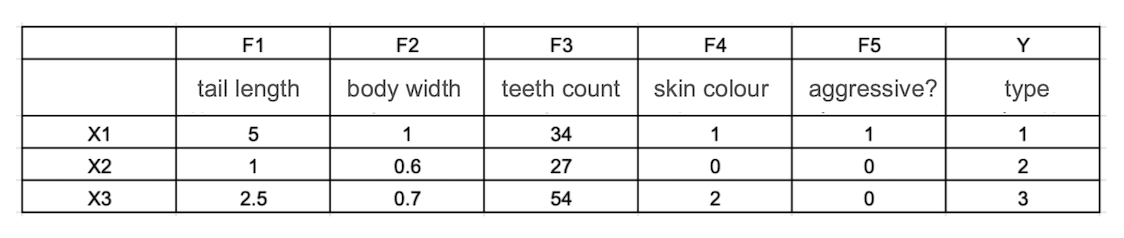

The simplest idea of neural network architecture for this task would be having one output neuron, which would output the class number of input object.

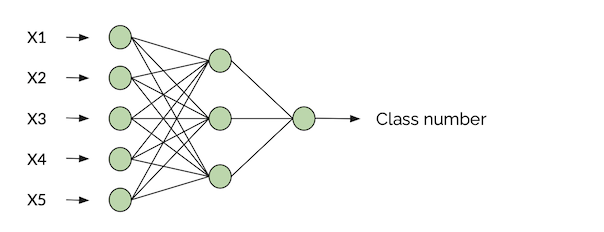

But there's a problem: how do we interpret outputs of such network? Let's say for some object our network outputs the value of 2.12. Does it mean that most likely our object belongs to the class 2? Or does the network think that the object is somewhere in between classes 1 and 3?

Okay, this was not the greatest idea. Let's now note, that a task of milti-class classification to $n$ classes can be wieved as $n$ binary classification tasks:
- does element belong to class 1?
- does element belong to class 2?
- ...
- does element belong to class n?

We can then make our neural network have n output neurons with Sigmoid activation function, and each output neuron will solve a corresponding binary classification tasks. So in our case with crocodile data it will look like that:


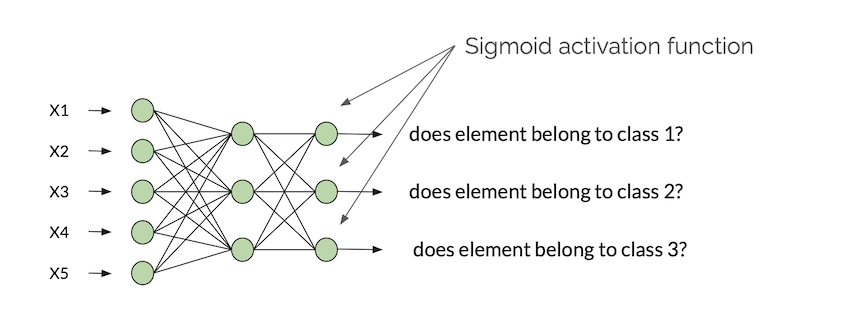

Such a network structure is suitable for the task of multi-label classification, where each input object can belong to arbitrary number of classes, i.e. where events "input object X belongs to class i" are independent. In the case of multi-class classification, these events are not independent, as each object can only belong to one class. So we would like decisions of neuron of the last layer to be agreed in some way.

The idea that comes to mind is the following: we would like neurons of the last layer to output a probability distribution over the classes. This means that the output of $i^{th}$ neuron will represent a probability that the input object belongs to the class $i$.

We also know the true distribution for each object, which is represented as one-hot vector. So as a loss function we could use some similarity measure between the true and predicted distributions.

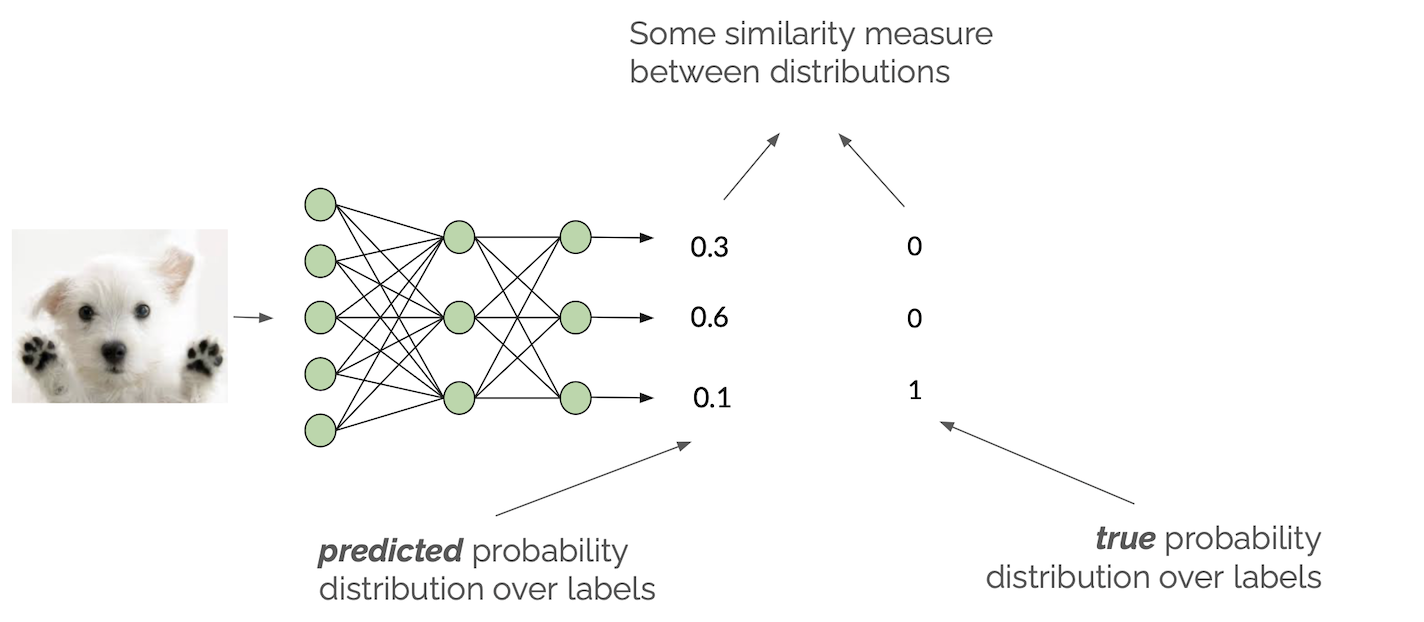

So we need to somehow convert the logits (outputs of the last linear layer) into the probability distribution. Let's do it using SoftMax activation function:

$$(p_1, p_2, p_3) = SoftMax(\widehat{p_1}, \widehat{p_2}, \widehat{p_3}) = \left( \frac{e^{\widehat{p_1}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_2}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_3}}}{\sum e^{\widehat{p_i}}} \right)$$

We can see that SoftMax does indeed convert logits into probability distribution, as the sum of all elements becomes 1, and value of each element is in $[0, 1]$.

And as a similarity measure between the output distribution and true distribution we will use [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy), which is a measure of similarity of two probability distrubutions from information theory.

$$CE(y, p) = - \sum y_i log(p_i)$$

LogLoss is a binary version of cross-entropy.





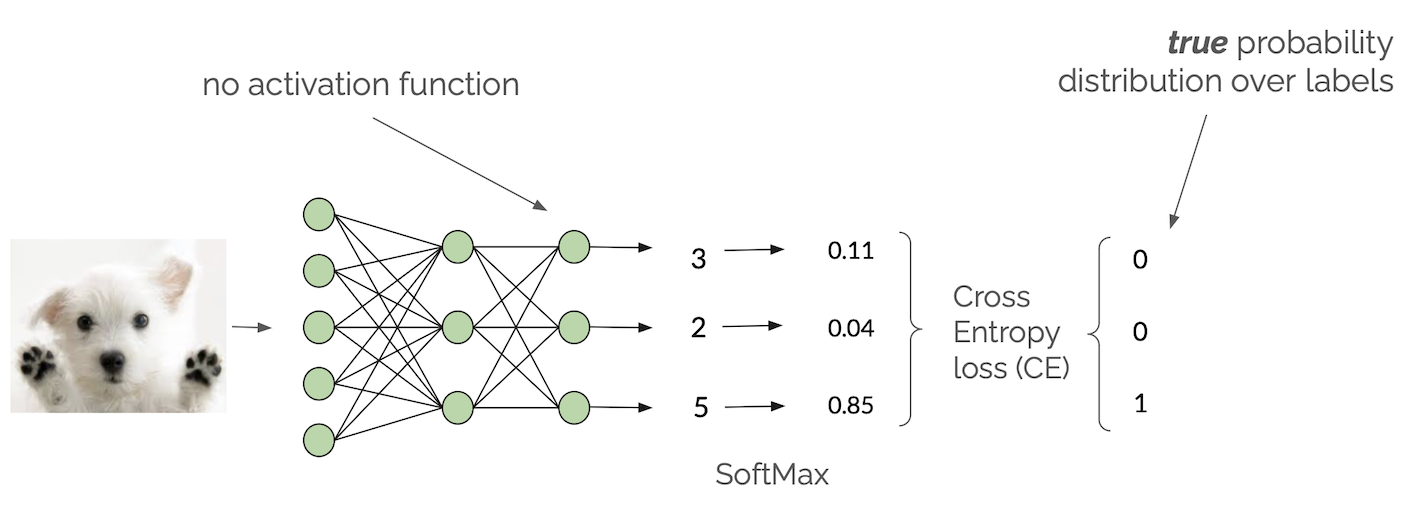

Let's also say a couple of words about why using SoftMax, as there are many ways to convert logits into probability distribution.

First, here's log function inside the formula of cross-entropy. If we pass logits $\widehat{p_i}$ through exponential function before feeding them into cross-entropy, we will end up $log(p_i)$ having the same magnitude as $\widehat{p_i}$. So this will encourage a neural network to output logits which have the same magnitude as $y_i$.

Second, SoftMax is a short for "Soft Maximum", and it has this name because it rebalances the values so that the maximum value becomes more pronounced, close to 1, while all other values get closer to zero.

Here's an example of how SoftMax changes logits:

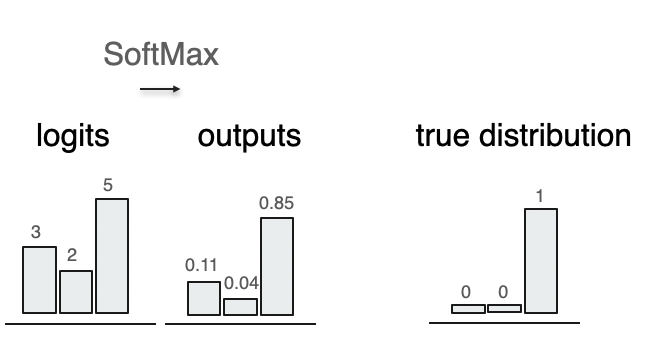

So it is called "Soft Maximum", as it acts almost like argmaximum function, but softer, not putting all the probability weight into one place.

To sum up, if you are building neural network for $n$-class classification task with $n>2$, then:
- last layer of the network should have $n$ neurons
- activation of the last layer of the network should be SoftMax (https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html)
- loss function is cross-entropy (https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

Note, however, that PyTorch implementation of CE (torch.nn.CrossEntropyLoss) expects to have logits as input, not probabilities after SoftMax. It applies SoftMax inside loss function. This is done due to efficiency of computing gradients. So if you use torch.nn.CrossEntropyLoss as loss function, there should be no activation function in the last layer of the network.

### Task 3.1 Write a neural network for multi-class classification

Define a class of neural network that should solve a multi-class classification task with 10 classes. Think about the following:
- How many input and output neurons you network should have?
- What activation function should the last layer have?

In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # define layers and activation function that your model will have
        self.fc1 = nn.Linear(784, 50)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(50, 10)
        self.act2 = nn.ReLU()

        self.fc3 = nn.Linear(10, 10)


    def forward(self, x):

        # define a flow of input through your layers
        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)

        return x

And create a network:

In [ ]:
net = Net()

### Task 3.2 Define a train function

You can copy it from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?

In [ ]:
import tqdm
from tqdm.auto import tqdm

# define a function
# you can change arguments of this function if you want
def train(model, dataloader, criterion, optimizer, num_epoch):
    pass

    for t in tqdm(range(num_epoch)):
        for X, y in dataloader:
            # getting our model's predictions on current batch
            y_pred = model(X.to(device))

            # getting loss value
            loss = criterion(y_pred.to(device), y.to(device))

            # zeroing previous gradient data
            optimizer.zero_grad()
            # calculate new gradients
            loss.backward()
            # optimization step
            optimizer.step()

    return model

And let's define loss function, optimizer, dataloader and train our network. For now use train_data_01 to pass to dataloader

In [ ]:
# loss function
criterion = torch.nn.CrossEntropyLoss()
# optimizer
optimizer = torch.optim.SGD(net.parameters(), lr=1e-2)
# dataloader
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_loader = train_loader = torch.utils.data.DataLoader(mnist_train_dataset, batch_size=64, shuffle=True)

# run training
net = train(net.to(device), train_loader, criterion, optimizer, 60)

  0%|          | 0/60 [00:00<?, ?it/s]

### Task 3.3. Write a code for model evaluation

Again, you can borrow the code from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?

In [ ]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch.to(device))

            # calculate loss function
            loss = criterion(y_pred.to(device), y_batch.to(device))
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred = np.argmax(y_pred.detach().cpu().numpy(), axis=1)

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = np.mean([x == y for x, y in zip(y_pred_list, y_true_list)])

    return np.mean(losses), accuracy

### Task 3.4 Train the neural network.

Here, again, your task is to make it better, so that your neural network can achieve >0.98 accuracy on the test part.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with no more than 2-3 hidden layers each having 5-7 neurons
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer?
- Play with number of layers, numbers of neurons in layers, different activation functions
- Try different training hyperparameters: learning rate, number of epochs, type of optimizer, batch size

After you've done experimenting, describe your findings. Try to answer the following questions:
- How large the neural network should be to solve the task successfully? There are two dimensions to the neural network size: **depth** (number of layers) and **width** (number of neurons in a layer).
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epoch needed to achieve the same value of loss function changes when you change activation function? Fix the network architecture and all the training hyperparameters and train the neural network with three different types of activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Here is also a hint on experimenting: try to change one parameter at time. When you change the parameter, retrain the network and see how the behaviour has changes. Log the results, so you can then a general picture of how each parameter influences the model training. This will also help you not to forget what you have already tried.





In [ ]:
test_loader = torch.utils.data.DataLoader(mnist_test_dataset, batch_size=64, shuffle=False)
evaluate(net, test_loader, criterion)

(0.10217265482987485, 0.9695)

That's it for the tasks in this notebook!

## Built-in datasets

MNIST is a toy dataset which is used in many AI classes and research papers. It is 'standard' in some sense. And many standard datasets can be accessed via PyTorch directly (see [documentation](https://pytorch.org/vision/main/datasets.html))

MNIST is a dataset of images, that is why it is available in torchvision.datasets module. So we could have loaded MNIST this way:


In [ ]:
import torchvision

mnist_train_dataset = torchvision.datasets.MNIST(root='./MNIST', train=True)
mnist_test_dataset = torchvision.datasets.MNIST(root='./MNIST', train=False)

mnist_train_dataset and mnist_test_dataset will be of torch.utils.data.Dataset type, just as Dataset we have implemented above. So we can now use these datasets directly in dataloaders:

In [ ]:
train_loader = torch.utils.data.DataLoader(mnist_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_test_dataset, batch_size=64, shuffle=False)